In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy
from matplotlib import cm
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


In [4]:
tmaxUTC = xr.open_dataset("/Projects/era5/Dailies/monolevel/tmax.2m.1941.nc")
tmaxUTC['lon'] = (tmaxUTC['lon'] + 180) % 360 - 180                                                                                                           
tmaxUTC = tmaxUTC.sortby(tmaxUTC.lon)
tmaxSLD = xr.open_dataset("/Projects/RAPrototype/ERA5/SolarDayTime/tmax.2m.1941.FromSolarDayTime.nc")
tmaxSLD['lon'] = (tmaxSLD['lon'] + 180) % 360 - 180                                                                                                           
tmaxSLD = tmaxSLD.sortby(tmaxSLD.lon)

In [12]:
FairbanksUTC = tmaxUTC['tmax'].sel(lat=64.8, lon=-147.8, method='nearest')
DenverUTC = tmaxUTC['tmax'].sel(lat=39.7, lon=-105.0, method='nearest')
SanFranciscoUTC = tmaxUTC['tmax'].sel(lat=37.8, lon=-122.4, method='nearest')
ChicagoUTC = tmaxUTC['tmax'].sel(lat=41.8, lon=-87.6, method='nearest')
NYCUTC = tmaxUTC['tmax'].sel(lat=40.7, lon=-74.0, method='nearest')


FairbanksSLD = tmaxSLD['tmax'].sel(lat=64.8, lon=-147.8, method='nearest')
DenverSLD = tmaxSLD['tmax'].sel(lat=39.7, lon=-105.0, method='nearest')
SanFranciscoSLD = tmaxSLD['tmax'].sel(lat=37.8, lon=-122.4, method='nearest')
ChicagoSLD = tmaxSLD['tmax'].sel(lat=41.8, lon=-87.6, method='nearest')
NYCSLD = tmaxSLD['tmax'].sel(lat=40.7, lon=-74.0, method='nearest')

In [13]:
UTC = [FairbanksUTC, DenverUTC, SanFranciscoUTC, ChicagoUTC, NYCUTC]
SLD = [FairbanksSLD, DenverSLD, SanFranciscoSLD, ChicagoSLD, NYCSLD]
tip = ['Fairbanks', 'Denver', 'SanFrancisco', 'Chicago', 'NYC' ]

/tmp/ipykernel_1770799/1329674429.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo')


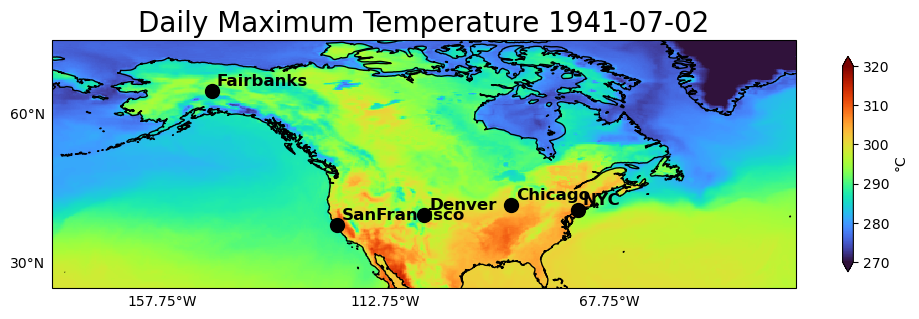

In [21]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(12,8),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=182).plot.pcolormesh(ax=ax,cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.35},vmin=270,vmax=320) 
for i in range(len(tip)):
    ax.plot(UTC[i]['lon'], UTC[i]['lat'], marker='o', color='black', markersize=10, transform=proj)
    ax.text(UTC[i]['lon']+1, UTC[i]['lat']+1, tip[i], fontsize=12, fontweight='bold', color='black', transform=proj)
gl1 = ax.gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax.add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax.set_extent([-180, -30, 25, 75], crs=ccrs.PlateCarree())
ax.set_title('UTC',fontsize=20)
custom_xticks = [0-180, 22.25-180, 67.25-180,112.25-180,157.25-180, 180-180, 202.25-180,247.25-180,292.25-180,337.25-180,360-180]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner

gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.title(f"Daily Maximum Temperature {tmaxUTC['time'][182].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()

In [22]:
CB_color = ['#377eb8', '#ff7f00', '#4daf4a',\
            '#e41a1c', '#a65628', '#984ea3',\
            '#999999', '#f781bf', '#dede00']

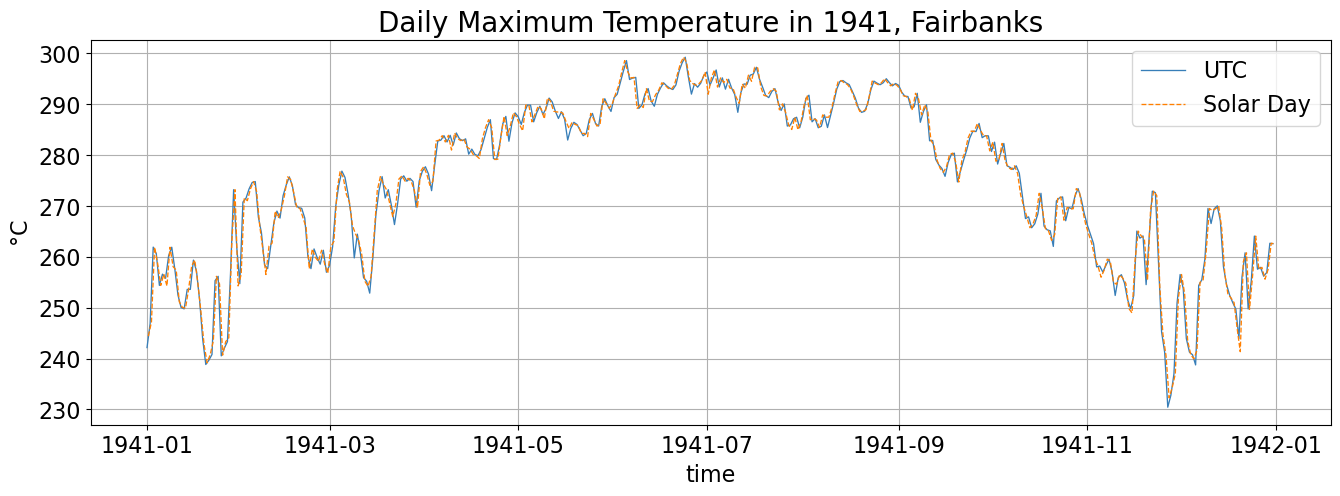

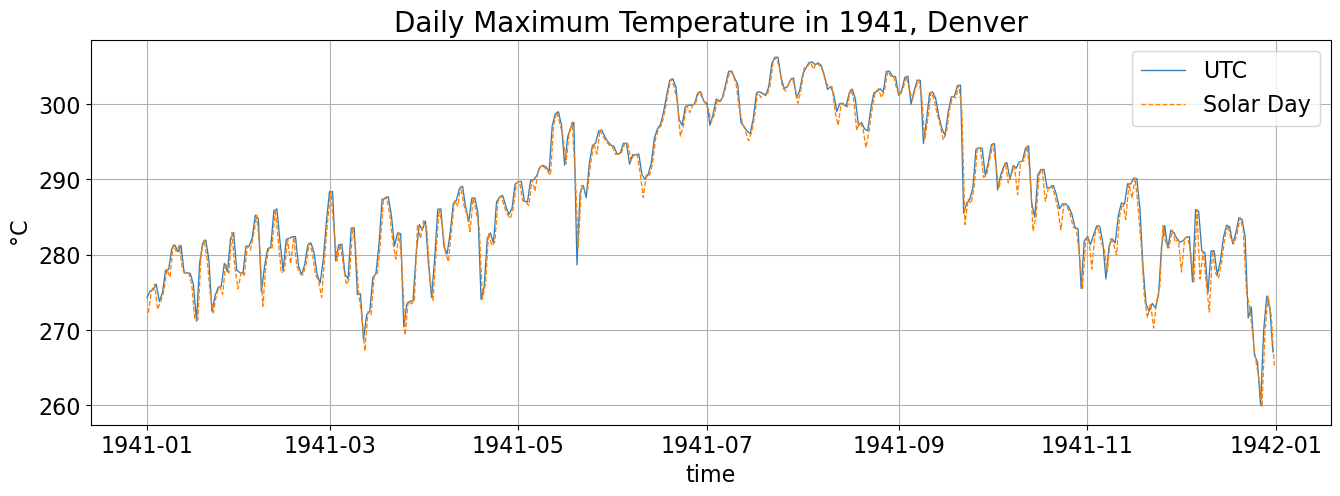

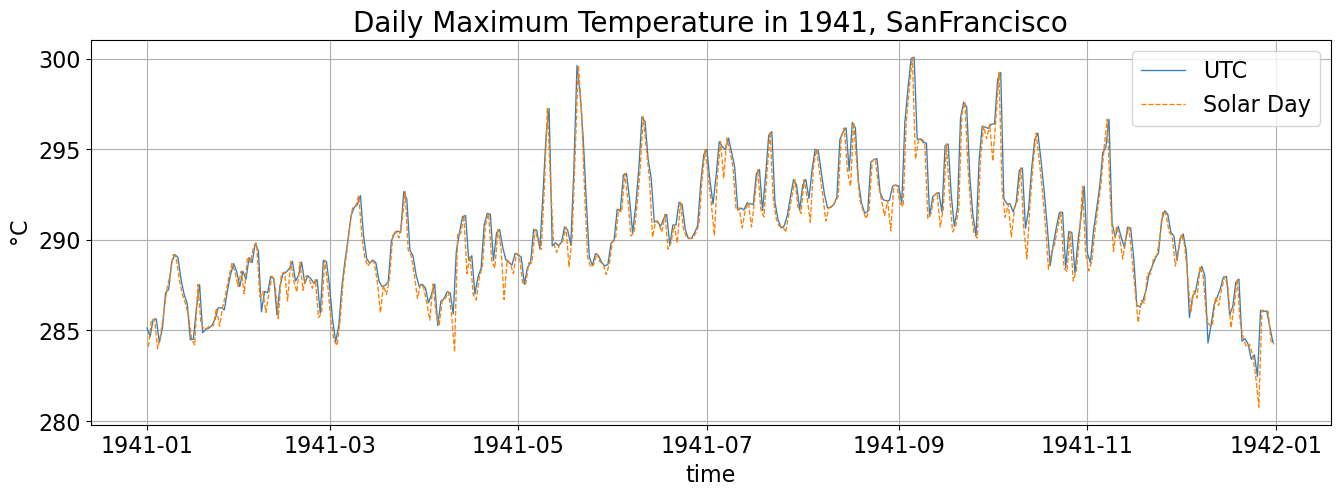

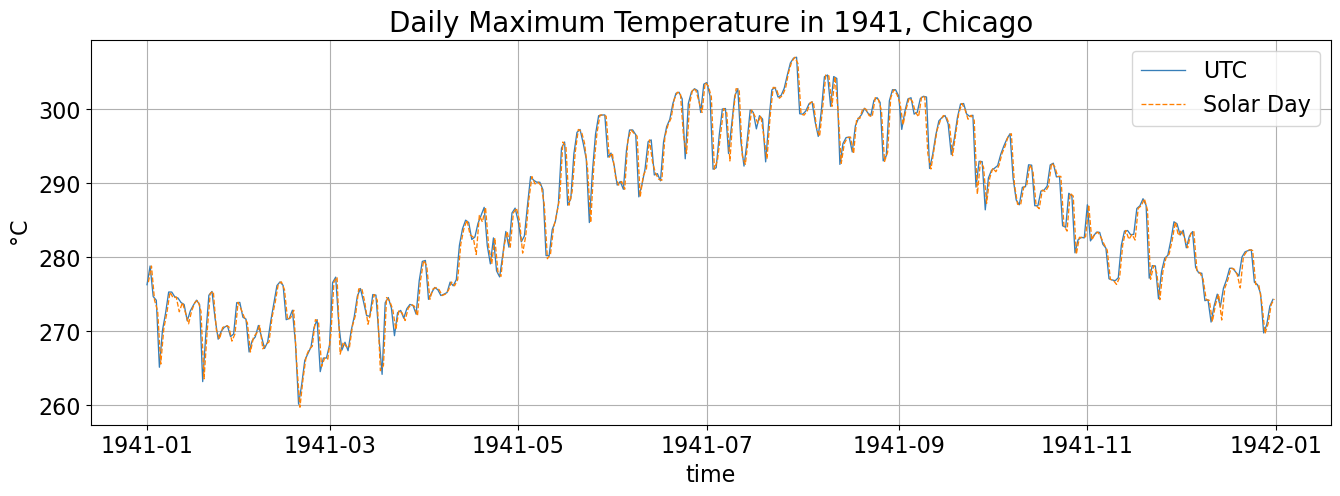

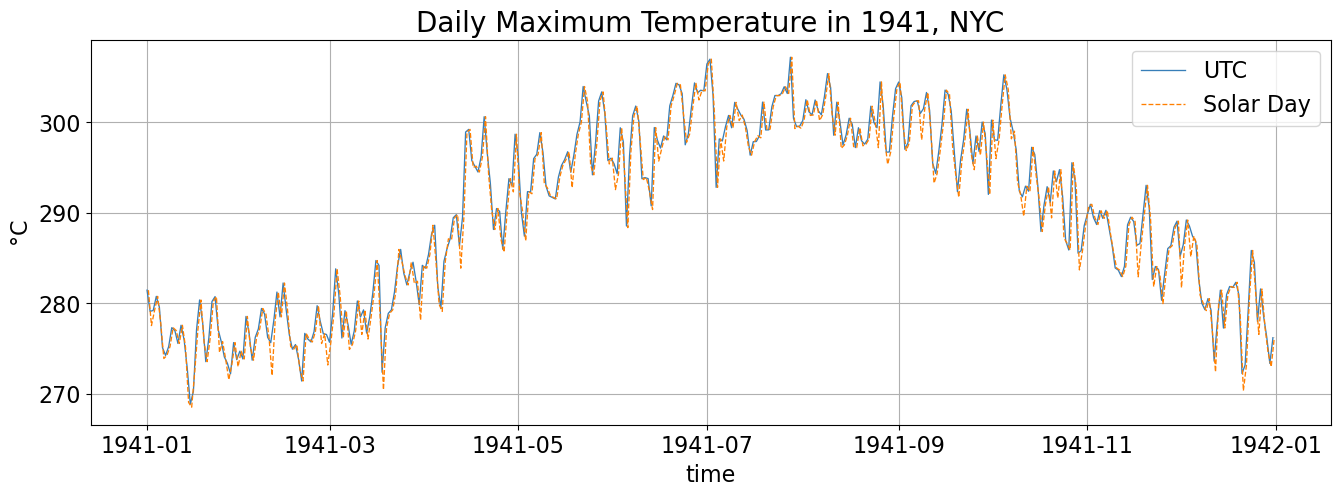

In [25]:
for ip in range(len(UTC)):

  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
  ax.plot(tmaxUTC['time'],UTC[ip],color=CB_color[0],linewidth=0.95,label='UTC')
  ax.plot(tmaxSLD['time'],SLD[ip],color=CB_color[1],linewidth=0.95,linestyle='--',label='Solar Day')
  ax.tick_params(labelsize=16)
  plt.legend(loc='best',prop={'size': 16})
  plt.grid(True)
  plt.ylabel(f'$\degree$C',fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'Daily Maximum Temperature in 1941, {tip[ip]}',fontsize=20)
  plt.show()

In [21]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

/tmp/ipykernel_1770799/188399294.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo')


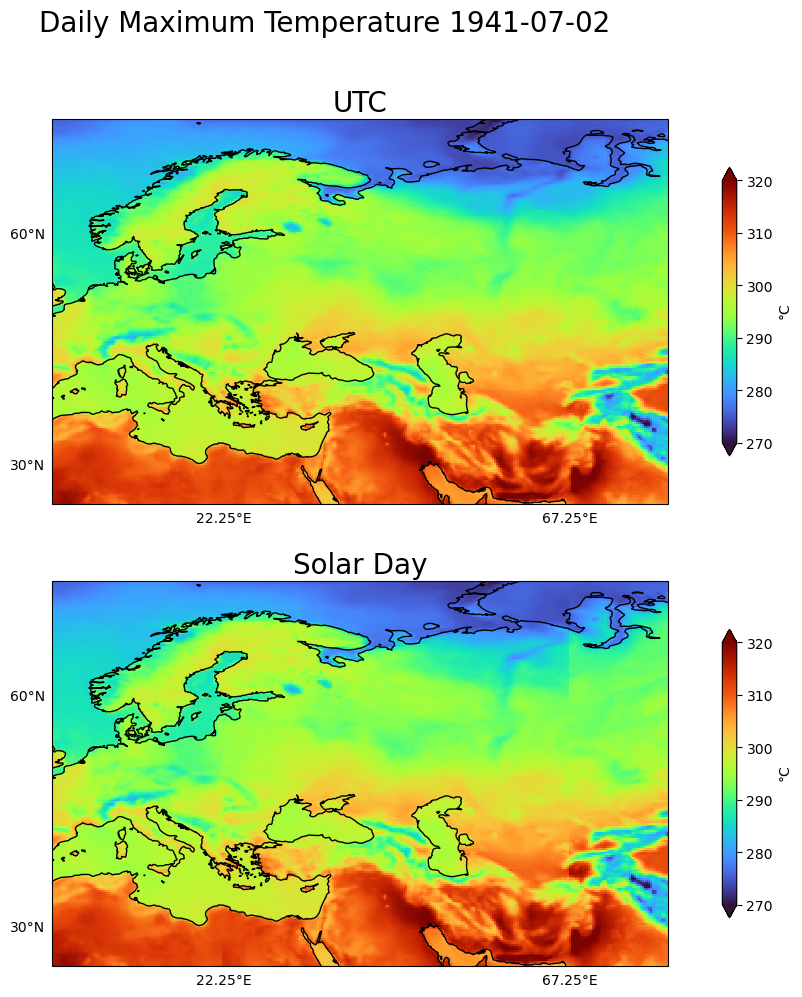

In [26]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(14,11),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=182).plot.pcolormesh(ax=ax[0],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=270,vmax=320) 
tmaxSLD['tmax'].isel(time=182).plot.pcolormesh(ax=ax[1],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=270,vmax=320)
gl0 = ax[0].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
gl1 = ax[1].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax[0].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[1].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[0].set_extent([0, 80, 25, 75], crs=ccrs.PlateCarree())
ax[1].set_extent([0, 80, 25, 75], crs=ccrs.PlateCarree())
ax[0].set_title('UTC',fontsize=20)
ax[1].set_title('Solar Day',fontsize=20)
custom_xticks = [0, 22.25, 67.25,112.25,157.25, 180, 202.25,247.25,292.25,337.25,360]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner
gl0.xlocator = mticker.FixedLocator(custom_xticks)
gl0.ylocator = mticker.FixedLocator(custom_yticks)
gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.suptitle(f"Daily Maximum Temperature {tmaxUTC['time'][182].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()

/tmp/ipykernel_1770799/924735740.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo')


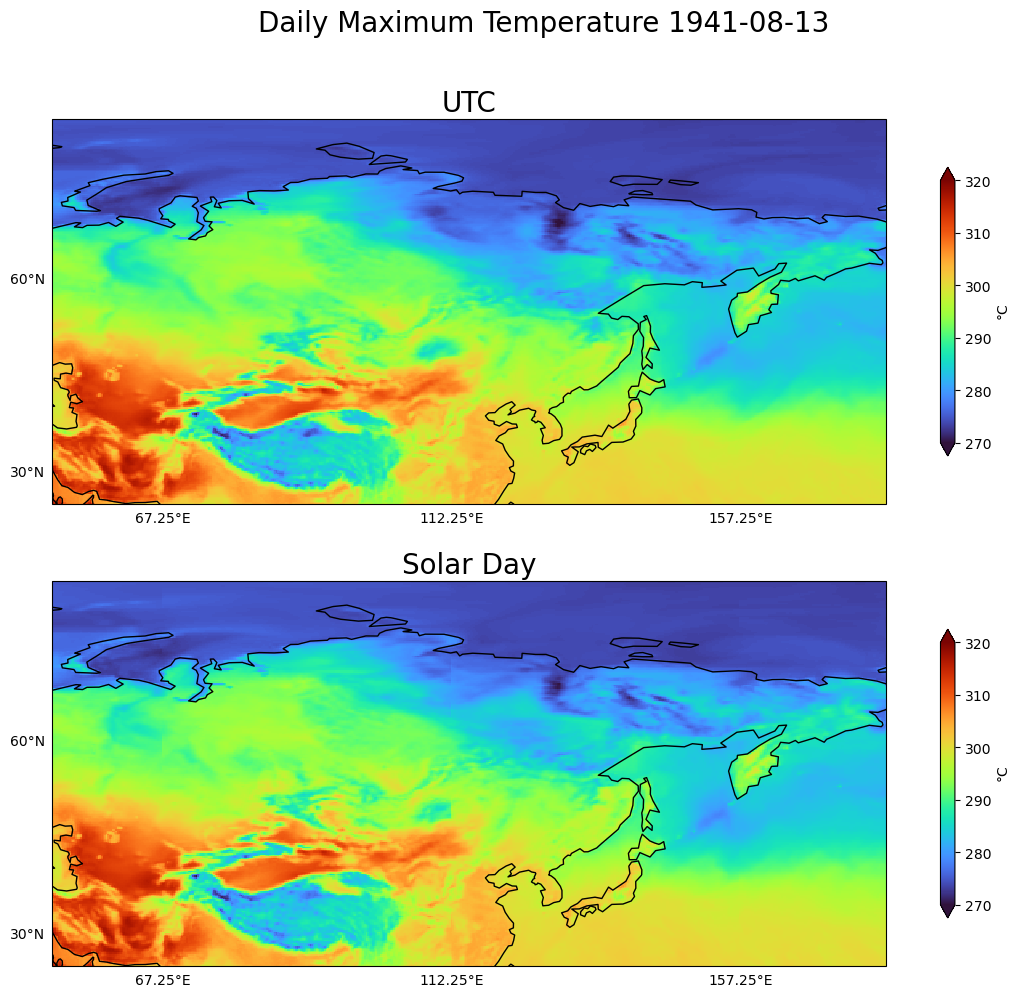

In [27]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(14,11),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=224).plot.pcolormesh(ax=ax[0],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=270,vmax=320) 
tmaxSLD['tmax'].isel(time=224).plot.pcolormesh(ax=ax[1],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=270,vmax=320)
gl0 = ax[0].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
gl1 = ax[1].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax[0].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[1].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[0].set_extent([50, 180, 25, 85], crs=ccrs.PlateCarree())
ax[1].set_extent([50, 180, 25, 85], crs=ccrs.PlateCarree())
ax[0].set_title('UTC',fontsize=20)
ax[1].set_title('Solar Day',fontsize=20)
custom_xticks = [0, 22.25, 67.25,112.25,157.25, 180, 202.25,247.25,292.25,337.25,360]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner
gl0.xlocator = mticker.FixedLocator(custom_xticks)
gl0.ylocator = mticker.FixedLocator(custom_yticks)
gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.suptitle(f"Daily Maximum Temperature {tmaxUTC['time'][224].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()

/tmp/ipykernel_1770799/2020615587.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo')


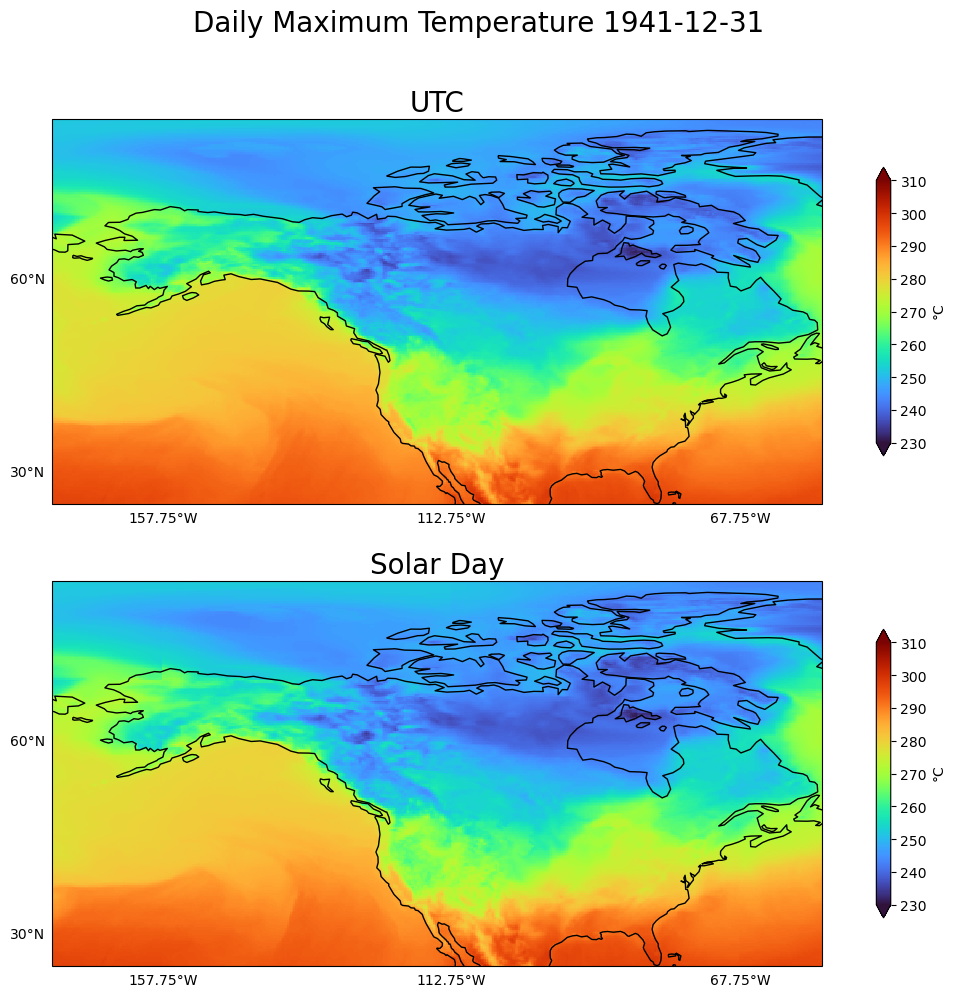

In [28]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(14,11),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=364).plot.pcolormesh(ax=ax[0],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=230,vmax=310) 
tmaxSLD['tmax'].isel(time=364).plot.pcolormesh(ax=ax[1],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=230,vmax=310)
gl0 = ax[0].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
gl1 = ax[1].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax[0].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[1].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[0].set_extent([185, 305, 25, 85], crs=ccrs.PlateCarree())
ax[1].set_extent([185, 305, 25, 85], crs=ccrs.PlateCarree())
ax[0].set_title('UTC',fontsize=20)
ax[1].set_title('Solar Day',fontsize=20)
custom_xticks = [202.25-360,247.25-360,292.25-360,337.25-360,360-360]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner
gl0.xlocator = mticker.FixedLocator(custom_xticks)
gl0.ylocator = mticker.FixedLocator(custom_yticks)
gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.suptitle(f"Daily Maximum Temperature {tmaxUTC['time'][364].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()